In [ ]:
from pathlib import Path
import sys

for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (base / "examples" / "path_setup.py").is_file():
        repo_root = base
        if str(repo_root) not in sys.path:
            sys.path.insert(0, str(repo_root))
        break
else:
    raise ModuleNotFoundError("Could not locate the PINNProof repository root relative to the notebook working directory.")

from examples.path_setup import configure_notebook_paths

REPO_ROOT = configure_notebook_paths()
print(f"Using PINNProof repo root: {REPO_ROOT}")

In [69]:
import matplotlib
%matplotlib inline

In [70]:
import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt

class SynchronousMachine(nn.Module):
    def __init__(self, 
                 D, P_m,
                 X_d_dash, X_q_dash,
                 X_d, X_q,
                 X_d_dash2, X_q_dash2,
                 H,
                 Rs, Re, Xep,        # <- add Xep to match dataset
                 T_d_dash, T_q_dash,
                 T_d_dd, T_q_dd,
                 E_fd,
                 omega_B=2*torch.pi*50.0):
        super().__init__()
        self.D, self.P_m, self.H = D, P_m, H
        self.X_d_dash, self.X_q_dash = X_d_dash, X_q_dash
        self.X_d, self.X_q = X_d, X_q
        self.X_d_dash2, self.X_q_dash2 = X_d_dash2, X_q_dash2
        self.Rs, self.Re, self.Xep = Rs, Re, Xep
        self.T_d_dash, self.T_q_dash = T_d_dash, T_q_dash
        self.T_d_dd, self.T_q_dd = T_d_dd, T_q_dd
        self.E_fd = E_fd
        self.omega_B = omega_B

        # EXACTLY like data generator: use transient + network (Xep) & Re
        A = torch.tensor([[self.Rs + self.Re,         -(self.X_q_dash + self.Xep)],
                          [ self.X_d_dash + self.Xep,  (self.Rs + self.Re)       ]],
                         dtype=torch.float32)
        self.register_buffer('A_inv', torch.linalg.inv(A))

    def _currents(self, theta, E_d_dash, E_q_dash, V_s, theta_vs):
        v_d = E_d_dash - V_s * torch.sin(theta - theta_vs)
        v_q = E_q_dash - V_s * torch.cos(theta - theta_vs)
        I_d = self.A_inv[0,0]*v_d + self.A_inv[0,1]*v_q
        I_q = self.A_inv[1,0]*v_d + self.A_inv[1,1]*v_q
        return I_d, I_q

    def interface(self, trajectory):
        """
        Given a trajectory tensor of shape (batch, time, 8):
        [δ, ω, E'_d, E'_q, E''_q, E''_d, V_t, θ_vs],
        compute and return (I_D, I_Q), each of shape (batch, time).
        """
        # Extract variables from trajectory
        δ     = trajectory[..., 0]  # Rotor angle
        E_d   = trajectory[..., 2]  # d-axis EMF
        E_q   = trajectory[..., 3]  # q-axis EMF
        V_t   = trajectory[..., 6]  # Terminal voltage magnitude
        θ_vs  = trajectory[..., 7]  # Voltage source phase

        # Compute d/q-axis voltages
        v_d = E_d - V_t * torch.sin(δ - θ_vs)
        v_q = E_q - V_t * torch.cos(δ - θ_vs)

        # Compute d/q-axis currents using inverse impedance matrix
        I_d = self.A_inv[0, 0] * v_d + self.A_inv[0, 1] * v_q
        I_q = self.A_inv[1, 0] * v_d + self.A_inv[1, 1] * v_q

        # Park transformation to D/Q frame (shift by π/2)
        cosρ = torch.cos(δ - torch.pi / 2)
        sinρ = torch.sin(δ - torch.pi / 2)

        I_D = I_d * cosρ - I_q * sinρ
        I_Q = I_d * sinρ + I_q * cosρ

        return I_D, I_Q

    def forward(self, t, y):
        # State ORDER must match your dataset (non-v2):
        # [θ, ω, E′d, E′q, E″d, E″q, V_s, θ_vs]
        theta, omega, E_d_dash, E_q_dash, E_d_dd, E_q_dd, V_s, theta_vs = torch.unbind(y)

        # algebraic currents (transient + Xep + Re)
        I_d, I_q = self._currents(theta, E_d_dash, E_q_dash, V_s, theta_vs)

        # electrical power (same as data gen)
        P_e = (E_d_dash * I_d
               + E_q_dash * I_q
               + (self.X_q_dash - self.X_d_dash) * I_d * I_q)

        # swing
        dtheta_dt = omega                                  # <- NO omega_B here
        domega_dt = (self.omega_B / (2*self.H)) * (self.P_m - P_e - self.D*omega)

        # EMF dynamics (same as odequations non-v2)
        dE_q_dash = (1.0/self.T_d_dash) * (-E_q_dash - (self.X_d - self.X_d_dash)*I_d + self.E_fd)
        dE_d_dash = (1.0/self.T_q_dash) * (-E_d_dash + (self.X_q - self.X_q_dash)*I_q)

        dE_q_dd   = (1.0/self.T_d_dd) * (E_q_dash - E_q_dd + (self.X_d_dash - self.X_d_dash2)*I_d)
        dE_d_dd   = (1.0/self.T_q_dd) * (E_d_dash - E_d_dd - (self.X_q_dash - self.X_q_dash2)*I_q)

        dV_s      = torch.tensor(0.0, device=y.device)
        dtheta_vs = torch.tensor(0.0, device=y.device)

        return torch.stack([dtheta_dt, domega_dt,
                            dE_d_dash, dE_q_dash,
                            dE_d_dd,   dE_q_dd,
                            dV_s,      dtheta_vs])


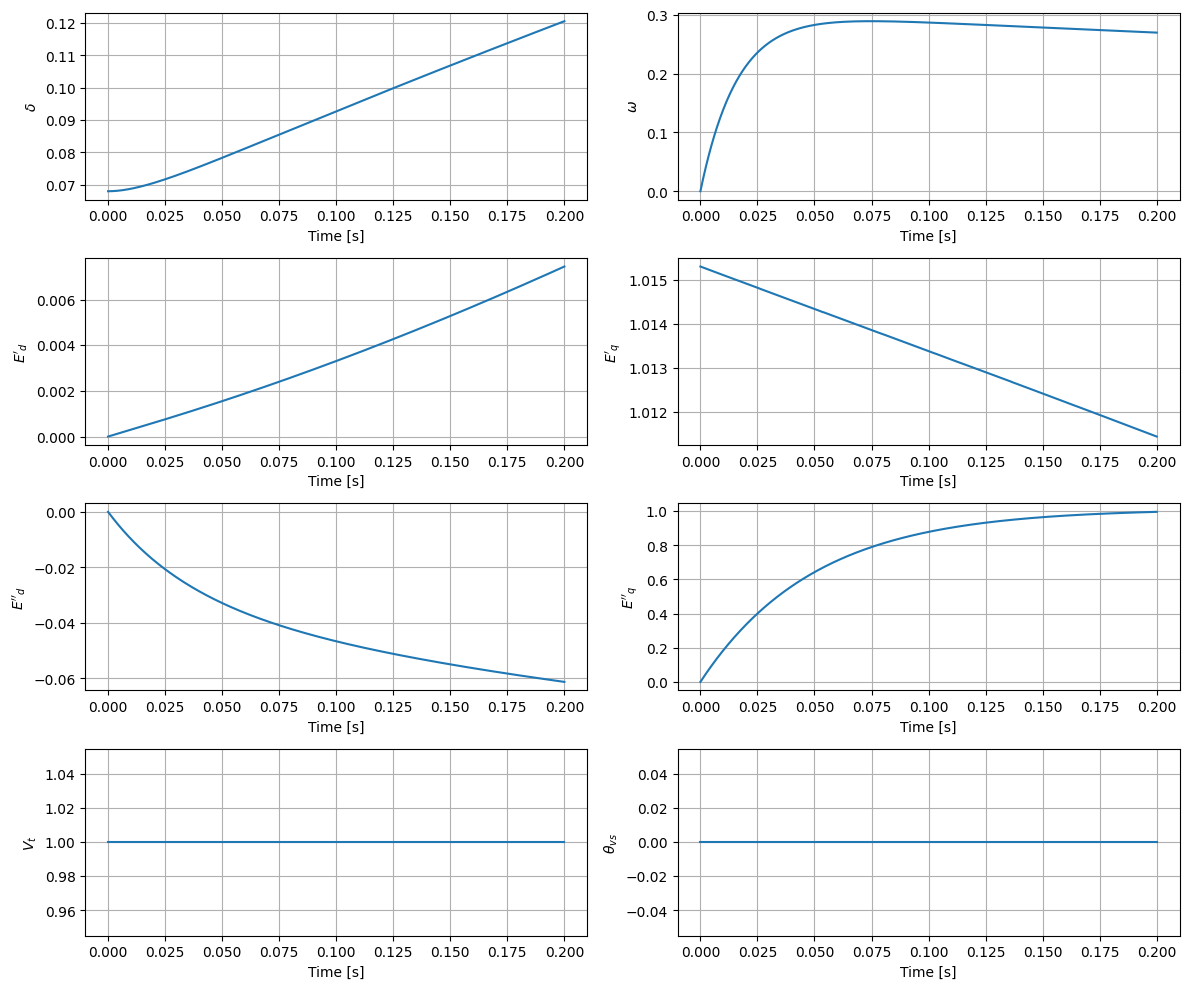

In [71]:
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint
from src.solvers.solver import Solver           # your base classes
from src.solvers.ODE_conventional import ODE_conventional

# 1) Time‐vector and constant Vs profile
t_final, num_points = 0.2, 1000
t_tensor = torch.linspace(0., t_final, num_points)
Vs       = torch.ones(num_points)   # 1.0 pu
θs       = torch.zeros(num_points)  # 0 rad
# We'll embed Vs and θs directly into the state, so no extra stack needed here.

# 2) Machine parameters & instantiation
params = {
    'D'         : 2.0,
    'P_m'       : 0.70,
    'X_d'       : 1.25,
    'X_q'       : 1.22,
    'X_d_dash'  : 0.232,
    'X_q_dash'  : 0.715,
    'X_d_dash2' : 0.20,   # X_d''
    'X_q_dash2' : 0.25,   # X_q''
    'H'         : 5.06,
    'Rs'        : 0.0,
    'Re'        : 0.0,
    'Xep'       : 0.0,
    'T_d_dash'  : 4.75,
    'T_q_dash'  : 1.6,
    'T_d_dd'    : 0.05,   # T_d''
    'T_q_dd'    : 0.04,   # T_q''
    'E_fd'      : 1.0
}

# params = {
#     'D'         : 2,
#     'P_m'       : 0.71,
#     'X_d_dash'  : 0.0608,
#     'X_q_dash'  : 0.0969,
#     'X_d'       : 0.146,
#     'X_q'       : 0.0969,
#     'X_d_dash2' : 0.03,
#     'X_q_dash2' : 0.04,
#     'H'         : 5.06,
#     'Rs'        : 0.0,
#     'Re'        : 0.0,
#     'T_d_dash'  : 8.96,
#     'T_q_dash'  : 0.31,
#     'T_d_dd'    : 0.5,
#     'T_q_dd'    : 0.25,
#     'E_fd'      : 1
# }
# D: 2
# E_fd: 1
# H: 5.06
# P_m: 0.7
# Rs: 0
# T_d_dash: 4.75
# T_q_dash: 1.6
# X_d: 1.25
# X_d_dash: 0.232
# X_q: 1.22
# X_q_dash: 0.715
# X_d_dash_dash: 0.2 #kundur p.153
# T_d_dash_dash: 0.05
# X_q_dash_dash: 0.25
# T_q_dash_dash: 0.04
machine = SynchronousMachine(**params)

# 3) Wrap into your conventional ODE solver
#    forward: (t,y)->dy/dt, interface: (batch, time, 8)->(I_D,I_Q)
solver = ODE_conventional(machine.forward, machine.interface)

# 4) Build the 8-dim initial state [δ₀, ω₀, E′d₀, E′q₀, E″q₀, E″d₀, V_s₀, θ_s₀]
δ0       = 0.0680
ω0       = 0.0
E_d0     = 0.0
E_q0     = 1.0153
E_q_dd0  = 0.0
E_d_dd0  = 0.0
V_s0     = Vs[0].item()   # 1.0
θ_s0     = θs[0].item()   # 0.0
x0 = torch.tensor([δ0, ω0, E_d0, E_q0,E_d_dd0, E_q_dd0, V_s0, θ_s0],
                  dtype=torch.float32)

# 5) Solve!
t_sol, sol = solver.solve(x0, t_final, num_points)
# sol has shape (num_points, 8)

# 6) Extract rotor states
delta  = sol[:, 0]
omega  = sol[:, 1]
E_d    = sol[:, 2]
E_q    = sol[:, 3]

#import matplotlib.pyplot as plt

# assume t_sol (num_points,) and sol (num_points, 8) are from your solver
# sol[:,i] corresponds to:
labels = [
    r"$\delta$",
    r"$\omega$",
    r"$E'_d$",
    r"$E'_q$",
    r"$E''_d$",
    r"$E''_q$",
    r"$V_t$",
    r"$\theta_{vs}$"
]

fig, axs = plt.subplots(4, 2, figsize=(12, 10))
axs = axs.flatten()

for i in range(8):
    axs[i].plot(t_sol, sol[:, i].detach())
    axs[i].set_ylabel(labels[i])
    axs[i].set_xlabel("Time [s]")
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [32]:
# V_profile.shape

In [72]:
# Define initial‐condition ranges for every state in [δ, ω, E′d, E′q, E″q, E″d, V_t, θ_vs]
ic_ranges = {
    'delta'     : (-0.5,  0.5),   # rotor angle [rad]
    'omega'     : (-0.25, 0.25),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (1.0,   1.0),   # transient q‐axis emf fixed
    'E_q_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_d_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.9875,   1.0125),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.075,  0.075),   # terminal voltage angle [rad]
}
# - {name: theta, range: [-2, 2], iterations: 7}
# - {name: omega, range: [-1, 1], iterations: 7}
# - {name: E_d_dash, range: [0], iterations: 1}
# - {name: E_q_dash, range: [0.9, 1.1], iterations: 5}
# - {name: E_d_dash_dash, range: [0], iterations: 1}
# - {name: E_q_dash_dash, range: [1], iterations: 1}
# - {name: Vs, range: [0.95,1.05], iterations: 3}
# - {name: theta_vs, range: [-0.3,0.3], iterations: 4}

t, data, ics = solver.generate_dataset(
    ic_ranges=ic_ranges,
    num_ic=100,
    t_final=t_final,
    num_points=num_points
)


D:\Internship/DTU Copenhagen (summer 2025)/PINNProof\src\solvers\ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


In [73]:
I_D, I_Q = solver.interface(data)


In [35]:
import os
os.getcwd()
# Change to a new directory  
os.chdir("./PINNProof/PINNProof/")  
print("After Changing:", os.getcwd())


FileNotFoundError: [WinError 3] The system cannot find the path specified: './PINNProof/PINNProof/'

In [74]:
from pretrained_models.architectures import Network

In [75]:
model=Network(input_size=9, hidden_size=64, output_size=6, num_layers=3,activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_path = "examples/pretrained_models/SM6_LBFGS_seed7.pth"
# model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_with_data.pth"
model_path = "D:\Internship\DTU Copenhagen (summer 2025)\PINNProof\examples\pretrained_models\SM6DynamicNN_0.2s_with_data.pth"
model_data = torch.load(model_path, weights_only=True, map_location=device)
# Check if model_data contains the key 'model_state_dict'
if isinstance(model_data, dict) and 'model_state_dict' in model_data:
    state_dict = model_data['model_state_dict']
else:
    state_dict = model_data
    print(state_dict)
    print("Model state keys:", state_dict.keys())
    print("Expected model keys:", model.state_dict().keys())
model.load_state_dict(state_dict)

<All keys matched successfully>

# BUILD THE CONVENTIONAL SOLVER MODEL

In [76]:
class Conventional(nn.Module):
    '''Trying to utilise the already implemented ODE_conventional.py solver'''
    def __init__(self, solver_object):
        super(Conventional, self).__init__()
        self.solver_object = solver_object

    def forward(self, x):
        print(x.shape)
        x = x.squeeze()
        t_final = x[0]
        x0 = x[1:]
        print("passing to solver", x0.shape, t_final)
        t, sol = self.solver_object.solve(x0, t_final, 2)
        final_output = sol[-1][:6]
        return final_output

In [53]:
x = torch.tensor([0.5, 0.6, 0.7, 0.2, 0.1, 0.6, 0.9, 0.1, 0.3], dtype=torch.float32)
conventional = Conventional(solver)
y = conventional(x)

torch.Size([9])
passing to solver torch.Size([8]) tensor(0.5000)


# TESTING OTHER FUNCTIONS

In [77]:
from src.verification.utils import *

# For Petros' method, this one needs to be implemented after making necessary changes
ic_ranges_tensor = torch.tensor(list(ic_ranges.values()))
bounds_for_sampling = list(map(tuple, ic_ranges_tensor.tolist()))
samples = sampling_domain(bounds_for_sampling, 5)
print(samples.shape)

(390625, 8)


In [78]:
# Indrajit's method, simplified a bit (only used for testing that samples can be generated)
bounds_for_sampling = ic_ranges.copy()
bounds_for_sampling['t'] = (0.0, t_final)  # add the time bounds for all-in-one sampling before the lipschitz calc
samples = torch.tensor(generate_samples(bounds_for_sampling, 1500, 'random'))
print(samples.shape)

torch.Size([1500, 9])


In [79]:
conventional = Conventional(solver)  # this 'solver' object being passed is already defined in the SynchronousMachine class

In [80]:
from src.verification.verifier import verifier

example_verifier_1 = verifier(model, model, ic_ranges)  # note that ic_ranges does not include 't'
example_verifier_2 = verifier(model, conventional, ic_ranges)

In [81]:
# note that bounds_for_sampling contains 't' added to the end of ic_ranges
print("ic_ranges: ")
print(ic_ranges)
print("\nbounds_for_sampling: ")
print(bounds_for_sampling)

ic_ranges: 
{'delta': (-0.5, 0.5), 'omega': (-0.25, 0.25), 'E_d_dash': (0.0, 0.0), 'E_q_dash': (1.0, 1.0), 'E_q_dd': (0.0, 0.0), 'E_d_dd': (1.0, 1.0), 'V_t': (0.9875, 1.0125), 'theta_vs': (-0.075, 0.075)}

bounds_for_sampling: 
{'delta': (-0.5, 0.5), 'omega': (-0.25, 0.25), 'E_d_dash': (0.0, 0.0), 'E_q_dash': (1.0, 1.0), 'E_q_dd': (0.0, 0.0), 'E_d_dd': (1.0, 1.0), 'V_t': (0.9875, 1.0125), 'theta_vs': (-0.075, 0.075), 't': (0.0, 0.2)}


In [59]:
print(t.shape)
print(data.shape)
print(ics.shape)


torch.Size([1000])
torch.Size([100, 8, 1000])
torch.Size([100, 8])


In [82]:
# Find the result of gradient attack on model vs model
G = example_verifier_1.gradient_attack(model, model, bounds_for_sampling, num_steps=100, learning_rate=0.01, num_restarts=10)
print(G)

  Restart 1/10: New max error found: 0.000000
(0.0, tensor([0.2000, 0.5000, 0.2500, 0.0000, 1.0000, 0.0000, 1.0000, 1.0125, 0.0750]))


In [83]:
# Find the result of gradient attack on model vs conventional
G = example_verifier_2.gradient_attack(model, conventional, bounds_for_sampling, num_steps=100, learning_rate=0.01, num_restarts=10)
print(G)

torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<SelectBackward0>)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.2000, grad_fn=<Select

In [88]:
E

(0.081383116543293,
 array([ 0.08715255,  0.49820327,  0.20593378,  0.        ,  1.        ,
         0.        ,  1.        ,  0.99816294, -0.04280612]))

In [86]:
model(G[1])

tensor([ 0.0244,  0.3526, -0.0012,  0.9989,  0.0065,  1.0002],
       grad_fn=<ViewBackward0>)

In [18]:
model(G[1])

tensor([ 0.8039,  0.0399,  0.0526,  0.8617, -0.2647,  0.9009],
       grad_fn=<ViewBackward0>)

In [90]:
model(torch.tensor(E[1], dtype=torch.float32))

tensor([ 0.5005, -0.0188,  0.0166,  0.9917, -0.2457,  1.0064],
       grad_fn=<ViewBackward0>)

In [20]:
# Find the result of ECP on model vs model
E = example_verifier_1.every_call_counts(model, model, bounds_for_sampling, num_steps=100)
print(E)

(0.0, array([ 0.24364341, -0.51006622, -0.34444172,  0.        ,  1.        ,
        0.        ,  1.        ,  1.01301613,  0.05628373]))


In [87]:
# Find the result of ECP on model vs conventional
E = example_verifier_2.every_call_counts(model, conventional, bounds_for_sampling, num_steps=100)
print(E)

torch.Size([9])
passing to solver torch.Size([8]) tensor(0.1955)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.0143)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.1385)


D:\Internship/DTU Copenhagen (summer 2025)/PINNProof\src\solvers\ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


torch.Size([9])
passing to solver torch.Size([8]) tensor(0.1023)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.1990)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.0513)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.0028)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.0115)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.0330)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.1259)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.1888)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.1956)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.0378)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.1136)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.0499)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.0174)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.1501)
torch.Size([9])
passing to solver torch.Size([8]) tensor(0.0030)
torch.Size([9])
passing t

In [22]:
E

(0.30806687474250793,
 array([ 0.07108453,  0.98614647, -0.10301206,  0.        ,  1.        ,
         0.        ,  1.        ,  1.02366643, -0.13063431]))

In [21]:
from src.solvers.solver_nn import Solver_NN
import numpy as np

In [22]:
sample_solver_nn = Solver_NN(func=machine.forward, n_control=2, n_states=6, model=model)  # assuming states=6 for SM6, hence control=2 since number of inputs is 9

In [23]:
t, Y = sample_solver_nn.solve(ini_cond=[0.2, 0.3, -0.4, 0.1, 0.0, 0.6, 0.8, -0.18], t_final=2.0, num_points=100)  # random sample initial conditions, 8 in number excluding time variable
print(t.shape)
print(Y.shape)

(100,)
(100, 6)


In [24]:
bounds_for_sampling

{'delta': (-2, 2),
 'omega': (-1, 1),
 'E_d_dash': (0.0, 0.0),
 'E_q_dash': (1.0, 1.0),
 'E_q_dd': (0.0, 0.0),
 'E_d_dd': (1.0, 1.0),
 'V_t': (0.95, 1.05),
 'theta_vs': (-0.3, 0.3),
 't': (0.0, 1.0)}

In [25]:
# Find the residuals from this nn_solver object
R = sample_solver_nn.compute_residuals(bounds=bounds_for_sampling, num_trajectories=17, num_points=130)
print(R.shape)

torch.Size([17, 130, 6])


In [26]:
print(R)

tensor([[[-6.4830e+01,  2.0032e+01, -6.5341e+01, -6.4172e+01, -4.9130e+01,
          -6.7110e+01],
         [-4.2418e+01,  2.1024e+01, -4.3248e+01, -4.2092e+01, -2.9596e+01,
          -4.4640e+01],
         [-2.7645e+01,  2.2388e+01, -2.8664e+01, -2.7522e+01, -1.7186e+01,
          -2.9771e+01],
         ...,
         [ 1.4934e-02,  2.6686e+01, -1.5218e-02,  3.2435e-01,  6.6913e+00,
           5.2574e-01],
         [ 5.3967e-03,  2.6739e+01, -1.9968e-02,  3.1730e-01,  6.7475e+00,
           5.2011e-01],
         [-3.9668e-03,  2.6789e+01, -2.4613e-02,  3.1036e-01,  6.8035e+00,
           5.1477e-01]],

        [[ 1.8124e+02, -1.9013e+01,  1.8072e+02,  1.8109e+02,  1.6437e+02,
           1.7767e+02],
         [ 1.1424e+02, -2.1707e+01,  1.1474e+02,  1.1511e+02,  1.0086e+02,
           1.1204e+02],
         [ 7.2397e+01, -2.3277e+01,  7.3515e+01,  7.3879e+01,  6.1741e+01,
           7.1180e+01],
         ...,
         [-3.6119e-01,  2.2972e+01,  5.6303e-01,  4.8481e-01,  6.5801e+00,
    

In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def _edges_from_centers(x):
    """Compute bin edges from sorted centers (non-uniform OK)."""
    x = np.asarray(x)
    if x.size == 1:
        # single row: make a small band around it
        return np.array([x[0]-0.5, x[0]+0.5])
    mid = 0.5*(x[:-1] + x[1:])
    first = x[0] - (mid[0] - x[0])
    last  = x[-1] + (x[-1] - mid[-1])
    return np.concatenate(([first], mid, [last]))

def _time_edges(t0, t1, T):
    t = np.linspace(t0, t1, T)
    if T == 1:
        return np.array([t0-0.5, t1+0.5])
    dt = np.diff(t)
    left  = t[0] - dt[0]/2
    right = t[-1] + dt[-1]/2
    mids  = 0.5*(t[:-1] + t[1:])
    return np.concatenate(([left], mids, [right]))

def plot_residual_heatmaps_by_state_y(
    R,                    # (N, T, S) tensor/array
    y0s,                  # (N, 8) ICs; first 6 are the states
    t_bounds,             # (t0, t1)
    state_labels=None,    # list of S labels
    log_scale=True,
    eps=1e-12
):
    # to numpy
    if isinstance(R, torch.Tensor): R = R.detach().cpu().numpy()
    if isinstance(y0s, torch.Tensor): y0s = y0s.detach().cpu().numpy()
    N, T, S = R.shape
    assert y0s.shape[0] == N, "y0s must have N rows to match R."

    if state_labels is None:
        state_labels = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_q$", r"$E''_d$"]

    t0, t1 = t_bounds
    t_edges = _time_edges(t0, t1, T)

    # choose magnitude (log or linear)
    if log_scale:
        Rplot = np.log10(np.abs(R) + eps)
        cbar_label = r"$\log_{10}(|\mathrm{residual}|)$"
    else:
        Rplot = R
        cbar_label = "residual"

    for s in range(S):
        # y-axis = IC of state s
        yvals = y0s[:, s]
        order = np.argsort(yvals)
        y_sorted = yvals[order]
        Z = Rplot[order, :, s]                      # (N, T)

        y_edges = _edges_from_centers(y_sorted)     # (N+1,)

        plt.figure(figsize=(8, 4))
        # pcolormesh expects Z shape (len(y_edges)-1, len(t_edges)-1)
        plt.pcolormesh(t_edges, y_edges, Z, shading='auto')
        plt.colorbar(label=cbar_label)
        plt.xlabel("Time [s]")
        plt.ylabel(f"IC of {state_labels[s]}")
        plt.title(f"Residual heatmap vs time (y = {state_labels[s]})")
        plt.tight_layout()
        plt.show()


tensor([[ 2.2332e+01],
        [ 5.0006e+00],
        [ 8.4197e-01],
        [-1.1860e-01],
        [-3.4523e-01],
        [-4.2709e-01],
        [-4.7755e-01],
        [-5.0909e-01],
        [-5.2372e-01],
        [-5.2765e-01],
        [ 4.5012e+01],
        [ 1.0608e+01],
        [ 1.9894e+00],
        [-1.2237e-01],
        [-6.0965e-01],
        [-7.1624e-01],
        [-7.3881e-01],
        [-7.3899e-01],
        [-7.2917e-01],
        [-7.1526e-01],
        [-1.6029e+01],
        [-4.6596e+00],
        [-1.5694e+00],
        [-7.5064e-01],
        [-5.2224e-01],
        [-4.8619e-01],
        [-5.0779e-01],
        [-5.3299e-01],
        [-5.4544e-01],
        [-5.4680e-01],
        [ 6.5283e+01],
        [ 1.5791e+01],
        [ 3.1781e+00],
        [-6.8279e-02],
        [-8.5531e-01],
        [-1.0134e+00],
        [-1.0222e+00],
        [-9.9793e-01],
        [-9.6671e-01],
        [-9.3587e-01],
        [ 8.8006e+01],
        [ 2.1701e+01],
        [ 4.9212e+00],
        [ 5

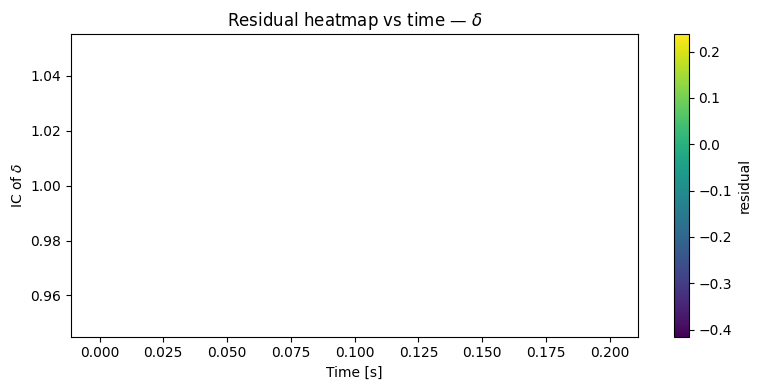

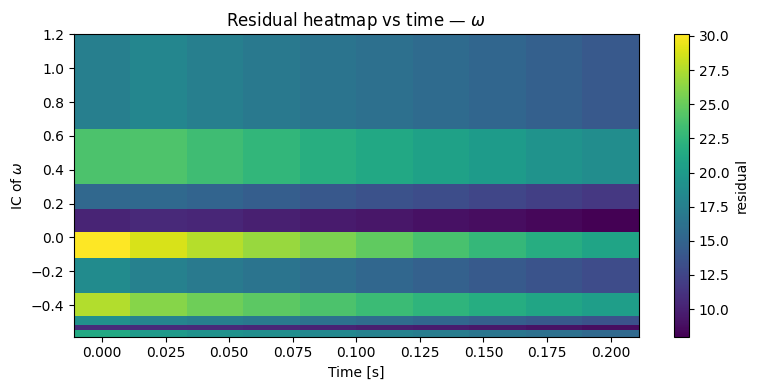

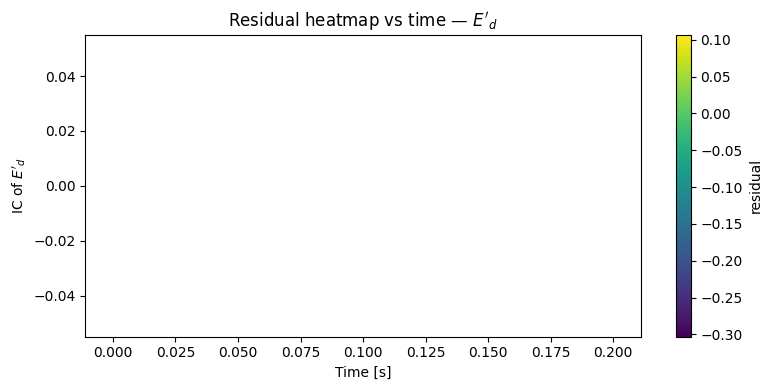

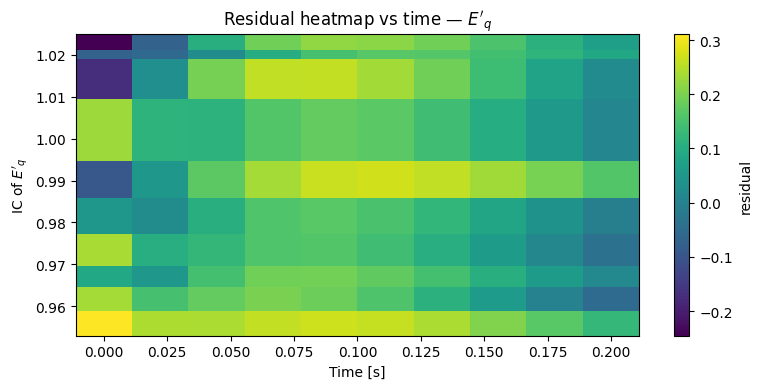

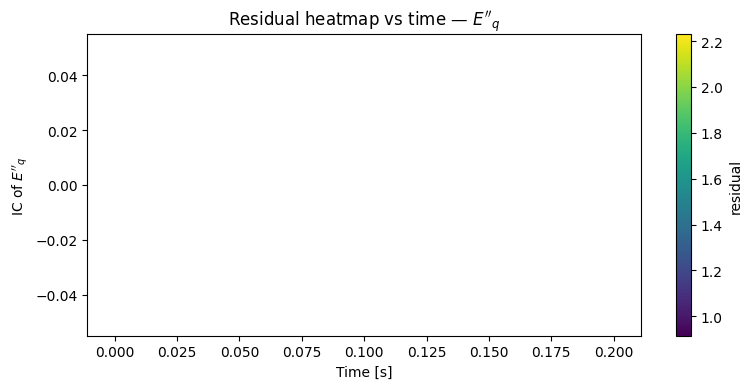

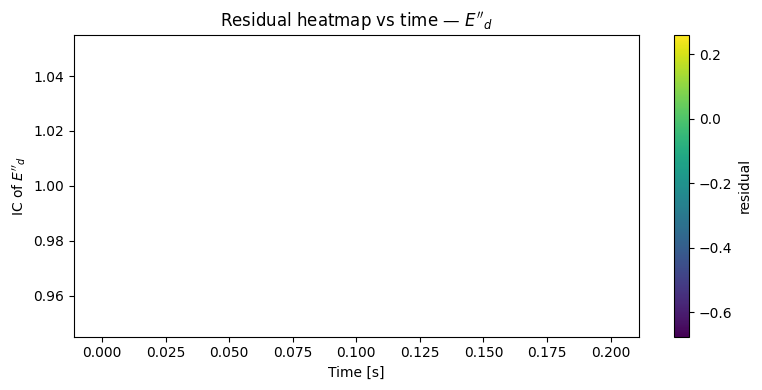

In [27]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from pathlib import Path

def pinn_residual_heatmaps_by_state_y(
    solver,                    # your Solver_NN (needs .model, .func, .n_states, .generate_batched_samples)
    bounds,                    # dict with keys for 8 states + 't'
    num_trajectories: int,
    num_points: int,
    *,
    outputs_are_slopes: bool = False,
    state_labels = (r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_q$", r"$E''_d$"),
    log10: bool = False,
    eps: float = 1e-12,
    save_dir: str | None = None,
):
    """
    Computes residuals r = dy/dt - f(t,y) and plots one heatmap per state:
      x-axis: time, y-axis: IC value of the SAME state, color: residual magnitude.
    Returns (R, y0s): residual tensor (N,T,S) and the IC matrix (N,8).
    """
    def _edges_from_centers(x):
        x = np.asarray(x)
        if x.size == 1:
            return np.array([x[0] - 0.5, x[0] + 0.5])
        mid = 0.5 * (x[:-1] + x[1:])
        first = x[0] - (mid[0] - x[0])
        last  = x[-1] + (x[-1] - mid[-1])
        return np.concatenate(([first], mid, [last]))

    def _time_edges(t0, t1, T):
        t = np.linspace(t0, t1, T)
        if T == 1:
            return np.array([t0 - 0.5, t1 + 0.5])
        mids = 0.5 * (t[:-1] + t[1:])
        left  = t[0]  - (mids[0] - t[0])
        right = t[-1] + (t[-1] - mids[-1])
        return np.concatenate(([left], mids, [right]))

    # ------------------ sample ICs/time exactly once ------------------
    var_names = [k for k in bounds.keys() if k != 't']  # keep your order
    y0s, t_grid = solver.generate_batched_samples(bounds, var_names, num_trajectories, num_points)
    # Model device for autograd; func (machine.forward) will be run on CPU
    model_device = next(solver.model.parameters()).device

    y0s = y0s.to(model_device)
    t_grid = t_grid.to(model_device)

    # Flatten time (enable grad)
    t_vec = t_grid.reshape(-1, 1).clone().detach().requires_grad_(True)     # (N*T,1)
    # Repeat ICs per time step
    y0s_vec = y0s.repeat_interleave(num_points, dim=0)                       # (N*T, 8)

    # Split states/controls
    S = solver.n_states
    y0_states_vec = y0s_vec[:, :S]                                           # (N*T, 6)
    y0_ctrl_vec   = y0s_vec[:, S:] if y0s_vec.shape[1] > S else None         # (N*T, 2) or None
    # print(y0_states_vec,y0_ctrl_vec)
    # ------------------ forward PINN ------------------
    # Model input matches your solve(): [t, y0(8)]
    model_input = torch.cat([t_vec, y0s_vec], dim=1)                         # (N*T, 9)
    solver.model.eval()
    net_out = solver.model(model_input)                                      # (N*T, 6)

    # Reconstruct y(t)
    # if outputs_are_slopes:
    #     y_hat = y0_states_vec + net_out * t_vec                              # slopes -> states
    # else:
    y_hat = net_out                                                      # states directly

    # ------------------ dy/dt (per state) ------------------
    grads = []
    for k in range(S):
        gk = torch.autograd.grad(
            outputs=y_hat[:, k:k+1],
            inputs=t_vec,
            grad_outputs=torch.ones_like(y_hat[:, k:k+1]),
            create_graph=True,
            retain_graph=True #(k < S - 1)
        )[0]                                                                 # (N*T,1)
        grads.append(gk)
    dy_dt = torch.cat(grads, dim=1)                                          # (N*T,6)

    # ------------------ RHS f(t,y) on CPU (robust to device mix) ------------------
    # Detach y and move to CPU for machine.forward(t,y)
    y_hat_cpu   = y_hat.detach().cpu()
    y0_ctrl_cpu = y0_ctrl_vec.detach().cpu() if y0_ctrl_vec is not None else None
    y_full_cpu  = torch.cat([y_hat_cpu, y0_ctrl_cpu], dim=1) if y0_ctrl_cpu is not None else y_hat_cpu
    t_cpu       = t_vec.detach().cpu().squeeze(-1)

    f_list = []
    with torch.no_grad():
        for i in range(y_full_cpu.shape[0]):
            fi = solver.func(t_cpu[i], y_full_cpu[i])                        # (8,)
            f_list.append(fi)
    f_full = torch.stack(f_list, dim=0).to(dy_dt.dtype)                      # (N*T,8) on CPU
    f_val  = f_full[:, :S].to(model_device)                                  # back to model device

    # ------------------ residuals and reshape ------------------
    print(f_val[:,1:2]/(2 * torch.pi * 50.0)-dy_dt[:,1:2])
    R = (dy_dt - f_val).view(num_trajectories, num_points, S)                # (N,T,6)
    R_np   = R.detach().cpu().numpy()
    y0s_np = y0s.detach().cpu().numpy()

    # ------------------ plot heatmaps ------------------
    t0, t1 = bounds['t']
    t_edges = _time_edges(t0, t1, num_points)

    if log10:
        Z_title = r"$\log_{10}(|\mathrm{residual}|)$"
    else:
        Z_title = "residual"

    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)

    for s in range(S):
        # y-axis = IC of state s
        yvals   = y0s_np[:, s]                       # (N,)
        order   = np.argsort(yvals)
        y_sorted= yvals[order]
        Z       = R_np[order, :, s]
        # Zplot =np.abs(Z)
        Zplot   = np.log10(np.abs(Z) + eps) if log10 else Z
        y_edges = _edges_from_centers(y_sorted)

        plt.figure(figsize=(8, 4))
        plt.pcolormesh(t_edges, y_edges, Zplot, shading='auto')
        plt.colorbar(label=Z_title)
        plt.xlabel("Time [s]")
        plt.ylabel(f"IC of {state_labels[s]}")
        plt.title(f"Residual heatmap vs time — {state_labels[s]}")
        plt.tight_layout()
        if save_dir:
            plt.savefig(os.path.join(save_dir, f"residual_heatmap_{s}.png"), dpi=200)
        plt.show()

    return R, y0s_np
bounds_for_sampling= {
    't':(0,0.2),
    'delta'     : (1,  1),   # rotor angle [rad]
    'omega'     : (-1.0, 1),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (0.95,   1.05),   # transient q‐axis emf fixed
    'E_d_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_q_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.95,   1.05),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.3,  0.3),   # terminal voltage angle [rad]
}
R, y0s = pinn_residual_heatmaps_by_state_y(
    solver=sample_solver_nn,
    bounds=bounds_for_sampling,       # includes 't': (0.0, t_final)
    num_trajectories=10,
    num_points=10,
    outputs_are_slopes=False,         # set True if your net outputs slopes
    save_dir=None                     # or "figs/residuals"
)


In [ ]:
f_full

In [ ]:
R